# Advanced Python Project – Carbon Emission Dataset

This notebook is prepared for the Advanced Python project on the carbon emission dataset. It includes data loading, cleaning, exploratory analysis, multivariate analysis, time series analysis, and support for answering the required analytical questions.[file:3]

## 1. Import libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Load dataset

Upload `carbon_emission_dataset_with_Industry.csv` to Colab before running this cell.[file:3]

In [21]:
file_path = '/kaggle/input/datasets/omaralramamneh/carbon-emission-dataset-with-industry/carbon_emission_dataset_with_Industry.csv'
df = pd.read_csv(file_path)

print('Dataset Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())
print('\nDataset Info:')
df.info()
print('\nDescriptive Statistics:')
display(df.describe())

Dataset Shape: (18250, 22)

Columns:
['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh', 'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units', 'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode', 'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET', 'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent', 'Employment_Count', 'Public_Acceptance_Index', 'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent', 'Social_Impact_Score', 'Industry_Sectors']

First 5 rows:


,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,12.56,3040.12,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,35.39,12837.43,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,30.45,16985.65,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,49.55,18192.00,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,16.90,6704.86,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Company_ID                           18250 non-null  object 
 1   Date                                 18250 non-null  object 
 2   Sector                               18250 non-null  object 
 3   Total_Energy_Consumption_kWh         18250 non-null  float64
 4   Renewable_Energy_Consumption_kWh     18250 non-null  float64
 5   NonRenewable_Energy_Consumption_kWh  18250 non-null  float64
 6   Production_Output_Units              18250 non-null  float64
 7   Supply_Chain_Transport_km            18250 non-null  float64
 8   Supply_Chain_Transport_Mode          18250 non-null  object 
 9   Raw_Material_Usage_kg                18250 non-null  float64
 10  Carbon_Emission_tCO2e_TARGET         18250 non-null  float64
 11  Energy_Cost_U

,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score
count,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00,18250.00
mean,124776.99,43759.10,81017.89,5538.96,2734.81,44869.42,32.37,10600.98,1129.54,77.62,2734.35,0.62,299333.03,15.07,47.64,0.67
std,43106.62,24291.67,33957.85,2597.58,1300.15,20110.51,14.48,4532.90,590.41,10.11,1298.65,0.19,115674.90,5.79,15.09,0.16
min,50008.73,5041.20,20483.26,1000.47,500.38,10006.50,6.81,2524.20,155.74,60.00,500.00,0.30,100052.34,5.00,15.25,0.40
25%,87326.36,24455.50,53738.55,3273.99,1609.12,27439.33,20.97,6979.21,682.41,68.88,1603.00,0.46,199132.37,10.04,35.24,0.54
50%,124728.53,38888.00,77007.82,5556.40,2735.02,44803.63,30.15,10001.70,1012.14,77.66,2730.00,0.62,297477.13,15.10,47.66,0.68
75%,162042.96,59545.03,104085.37,7802.10,3862.72,62291.03,41.52,13621.39,1464.85,86.32,3853.75,0.79,399960.93,20.07,60.19,0.81
max,199988.91,119005.26,179431.02,9999.78,4999.89,79994.46,86.57,23880.69,4211.60,95.00,5000.00,0.95,499881.17,25.00,79.94,0.95


## 3. Standardize column names

In [22]:
df.columns = [col.strip() for col in df.columns]

rename_map = {
    'CompanyID': 'Company_ID',
    'Date': 'Date',
    'Sector': 'Sector',
    'TotalEnergyConsumptionkWh': 'Total_Energy_Consumption_kWh',
    'RenewableEnergyConsumptionkWh': 'Renewable_Energy_Consumption_kWh',
    'NonRenewableEnergyConsumptionkWh': 'NonRenewable_Energy_Consumption_kWh',
    'ProductionOutputUnits': 'Production_Output_Units',
    'SupplyChainTransportkm': 'Supply_Chain_Transport_km',
    'SupplyChainTransportMode': 'Supply_Chain_Transport_Mode',
    'RawMaterialUsagekg': 'Raw_Material_Usage_kg',
    'CarbonEmissiontCO2eTARGET': 'Carbon_Emission_tCO2e_TARGET',
    'EnergyCostUSD': 'Energy_Cost_USD',
    'CarbonTaxUSD': 'Carbon_Tax_USD',
    'ProcessEfficiencyPercent': 'Process_Efficiency_Percent',
    'EmploymentCount': 'Employment_Count',
    'PublicAcceptanceIndex': 'Public_Acceptance_Index',
    'CarbonReductionStrategy': 'Carbon_Reduction_Strategy',
    'StrategyImplementationCostUSD': 'Strategy_Implementation_Cost_USD',
    'ExpectedCarbonReductionPercent': 'Expected_Carbon_Reduction_Percent',
    'ExpectedRenewableSharePercent': 'Expected_Renewable_Share_Percent',
    'SocialImpactScore': 'Social_Impact_Score',
    'IndustrySectors': 'Industry_Sectors'
}

df.rename(columns=rename_map, inplace=True)
print(df.columns.tolist())

['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh', 'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units', 'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode', 'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET', 'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent', 'Employment_Count', 'Public_Acceptance_Index', 'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent', 'Social_Impact_Score', 'Industry_Sectors']


## 4. Data cleaning

In [23]:
print('Missing Values:')
display(df.isnull().sum())

print('Duplicate Rows:', df.duplicated().sum())
df = df.drop_duplicates()

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
category_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in category_cols:
    if df[col].mode().empty:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print('\nData types after cleaning:')
display(df.dtypes)

Missing Values:


Company_ID                             0
Date                                   0
Sector                                 0
Total_Energy_Consumption_kWh           0
Renewable_Energy_Consumption_kWh       0
NonRenewable_Energy_Consumption_kWh    0
Production_Output_Units                0
Supply_Chain_Transport_km              0
Supply_Chain_Transport_Mode            0
Raw_Material_Usage_kg                  0
Carbon_Emission_tCO2e_TARGET           0
Energy_Cost_USD                        0
Carbon_Tax_USD                         0
Process_Efficiency_Percent             0
Employment_Count                       0
Public_Acceptance_Index                0
Carbon_Reduction_Strategy              0
Strategy_Implementation_Cost_USD       0
Expected_Carbon_Reduction_Percent      0
Expected_Renewable_Share_Percent       0
Social_Impact_Score                    0
Industry_Sectors                       0
dtype: int64

Duplicate Rows: 0

Data types after cleaning:


Company_ID                                     object
Date                                   datetime64[ns]
Sector                                         object
Total_Energy_Consumption_kWh                  float64
Renewable_Energy_Consumption_kWh              float64
NonRenewable_Energy_Consumption_kWh           float64
Production_Output_Units                       float64
Supply_Chain_Transport_km                     float64
Supply_Chain_Transport_Mode                    object
Raw_Material_Usage_kg                         float64
Carbon_Emission_tCO2e_TARGET                  float64
Energy_Cost_USD                               float64
Carbon_Tax_USD                                float64
Process_Efficiency_Percent                    float64
Employment_Count                                int64
Public_Acceptance_Index                       float64
Carbon_Reduction_Strategy                      object
Strategy_Implementation_Cost_USD              float64
Expected_Carbon_Reduction_Pe

## 5. Basic statistics

In [24]:
selected_cols = [
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh',
    'Production_Output_Units',
    'Supply_Chain_Transport_km'
]

selected_cols = [c for c in selected_cols if c in df.columns]

basic_stats = df[selected_cols].agg(['mean', 'median', 'max', 'min']).T
display(basic_stats)

,mean,median,max,min
Total_Energy_Consumption_kWh,124776.99,124728.53,199988.91,50008.73
Renewable_Energy_Consumption_kWh,43759.10,38888.00,119005.26,5041.20
NonRenewable_Energy_Consumption_kWh,81017.89,77007.82,179431.02,20483.26
Production_Output_Units,5538.96,5556.40,9999.78,1000.47
Supply_Chain_Transport_km,2734.81,2735.02,4999.89,500.38


## 6. Univariate analysis

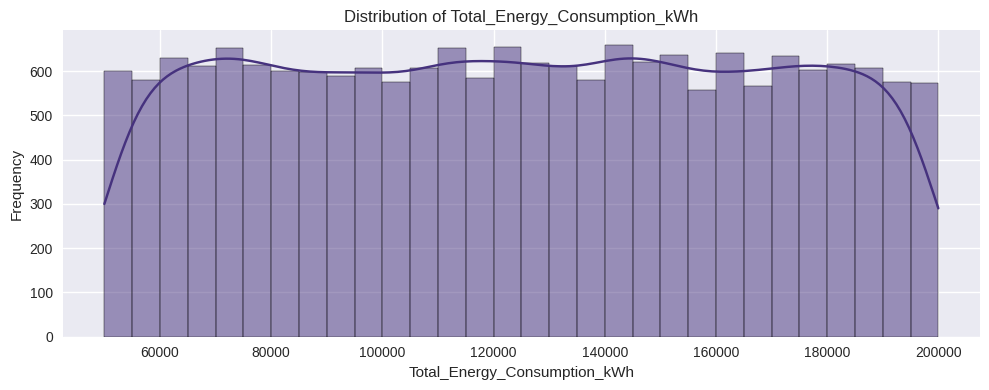

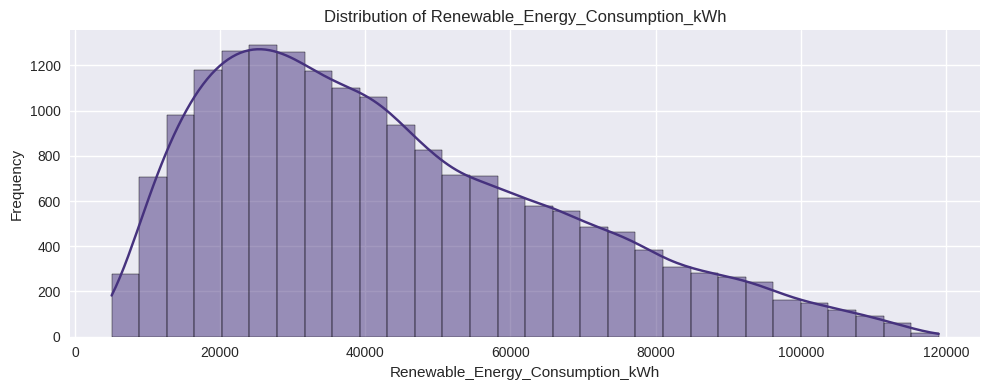

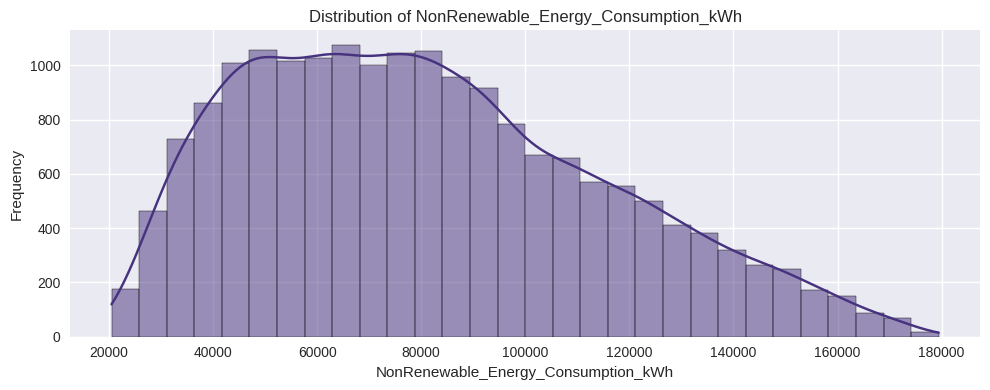

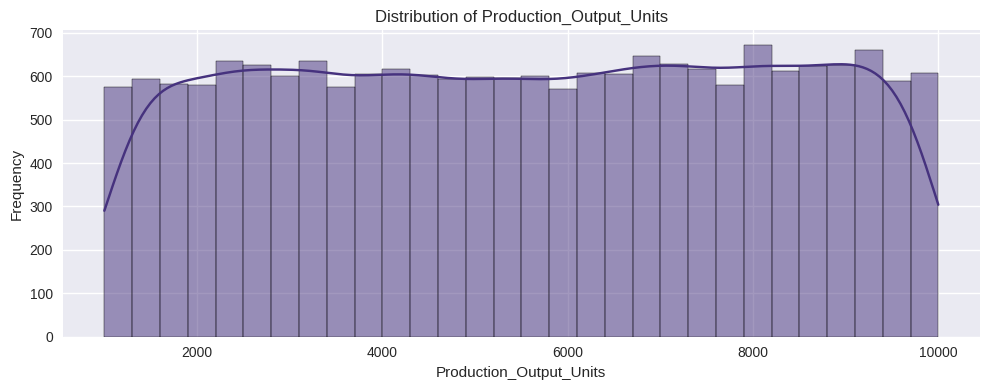

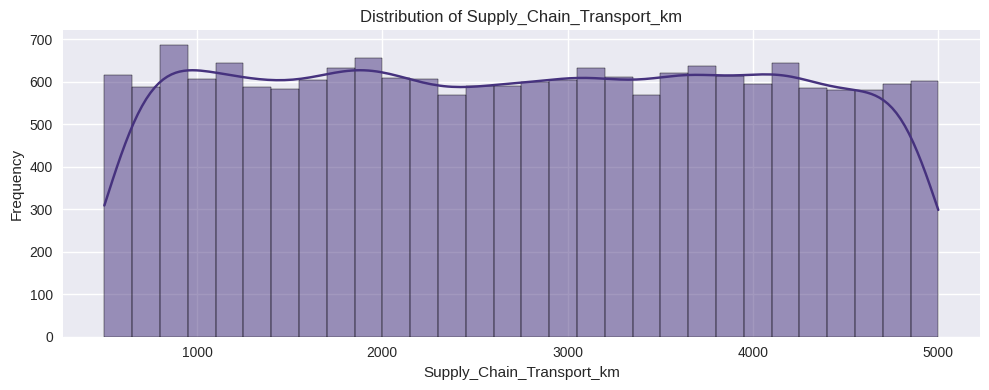

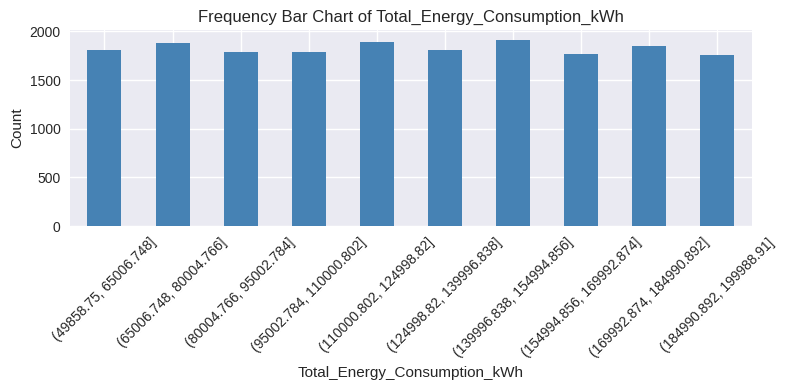

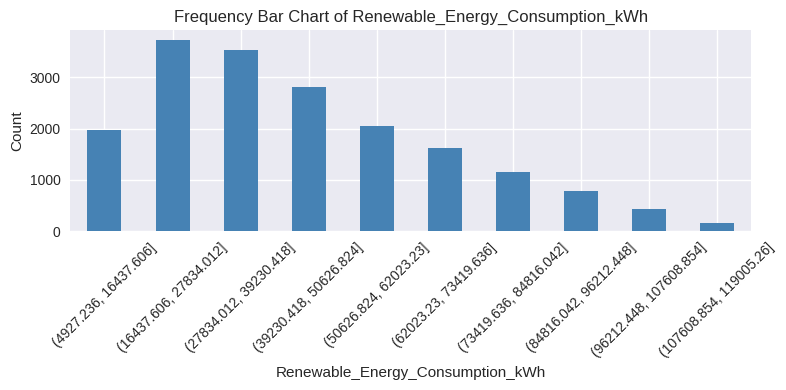

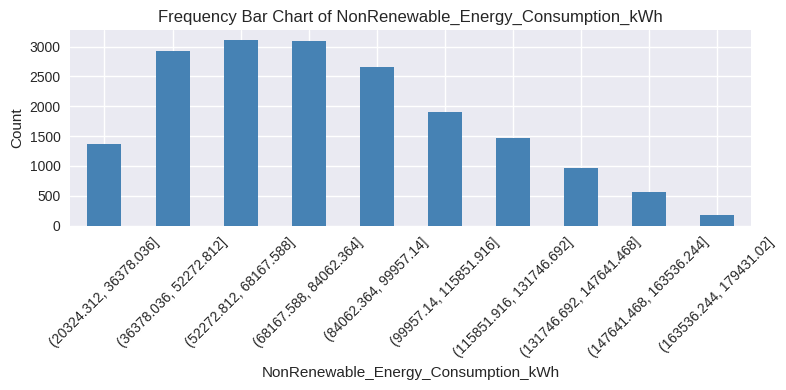

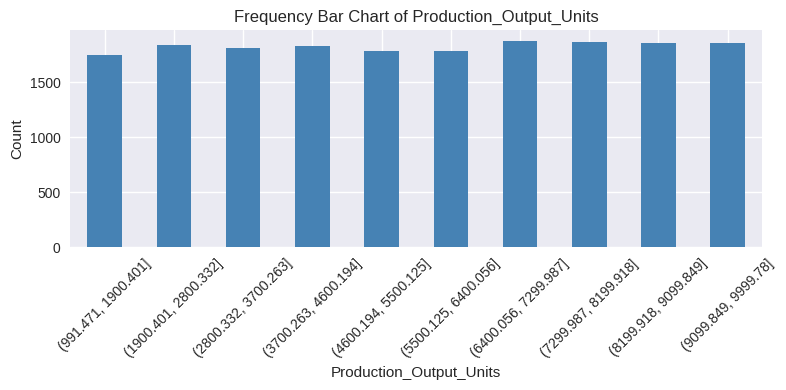

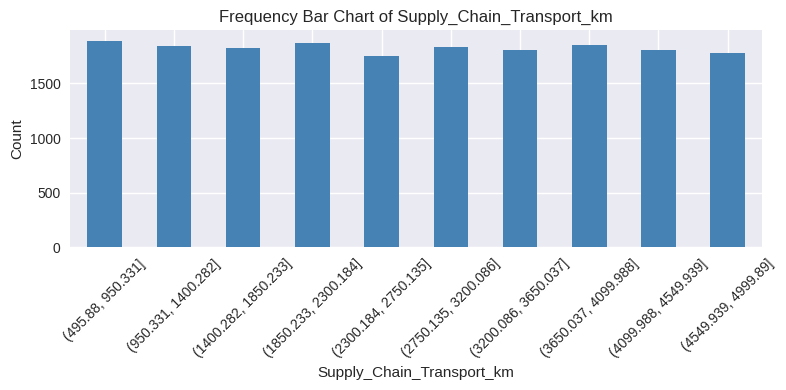

In [25]:
for col in selected_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

for col in selected_cols:
    plt.figure(figsize=(8, 4))
    binned = pd.cut(df[col], bins=10)
    binned.value_counts().sort_index().plot(kind='bar', color='steelblue')
    plt.title(f'Frequency Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Line plot of energies over time

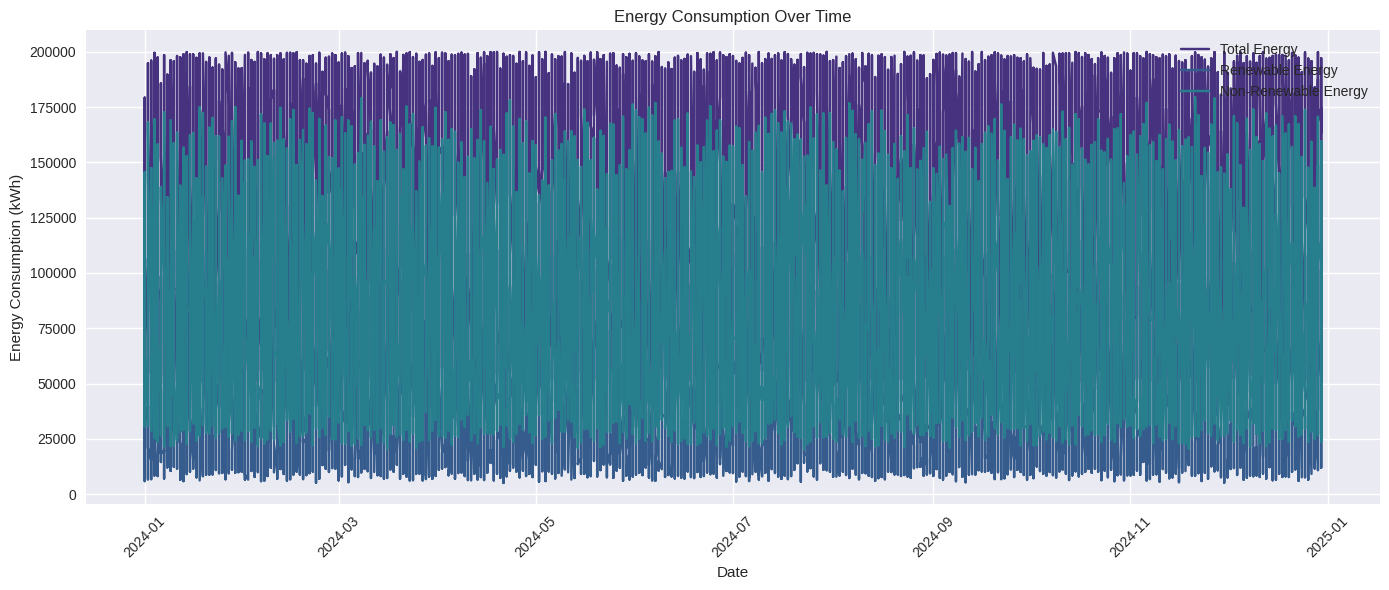

In [26]:
target_col = 'Carbon_Emission_tCO2e_TARGET'
temp_candidates = ['Temperature', 'Temperature_C', 'Avg_Temperature_C']
temp_col = next((c for c in temp_candidates if c in df.columns), None)

if 'Date' in df.columns:
    df_sorted = df.sort_values('Date')
    plt.figure(figsize=(14, 6))
    if 'Total_Energy_Consumption_kWh' in df.columns:
        plt.plot(df_sorted['Date'], df_sorted['Total_Energy_Consumption_kWh'], label='Total Energy')
    if 'Renewable_Energy_Consumption_kWh' in df.columns:
        plt.plot(df_sorted['Date'], df_sorted['Renewable_Energy_Consumption_kWh'], label='Renewable Energy')
    if 'NonRenewable_Energy_Consumption_kWh' in df.columns:
        plt.plot(df_sorted['Date'], df_sorted['NonRenewable_Energy_Consumption_kWh'], label='Non-Renewable Energy')
    plt.title('Energy Consumption Over Time')
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption (kWh)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Scatter plots

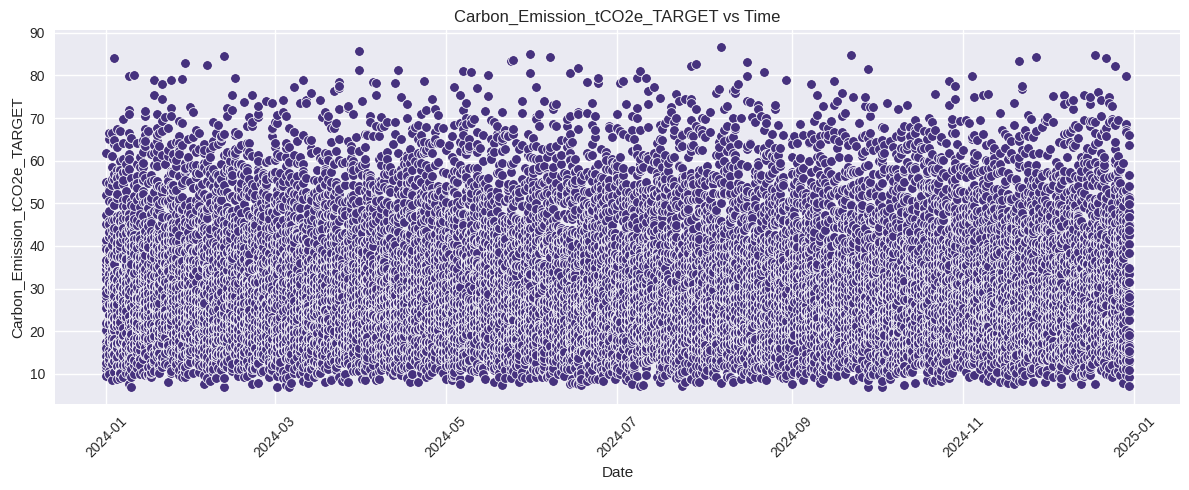

In [27]:
if temp_col is not None and target_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=temp_col, y=target_col)
    plt.title(f'{target_col} vs {temp_col}')
    plt.tight_layout()
    plt.show()

if 'Date' in df.columns and target_col in df.columns:
    plt.figure(figsize=(12, 5))
    sns.scatterplot(data=df_sorted, x='Date', y=target_col)
    plt.title(f'{target_col} vs Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Bivariate and multivariate analysis

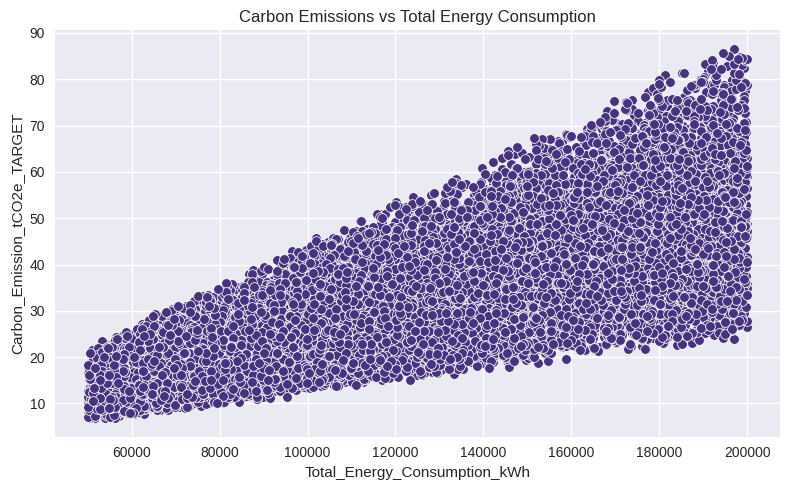

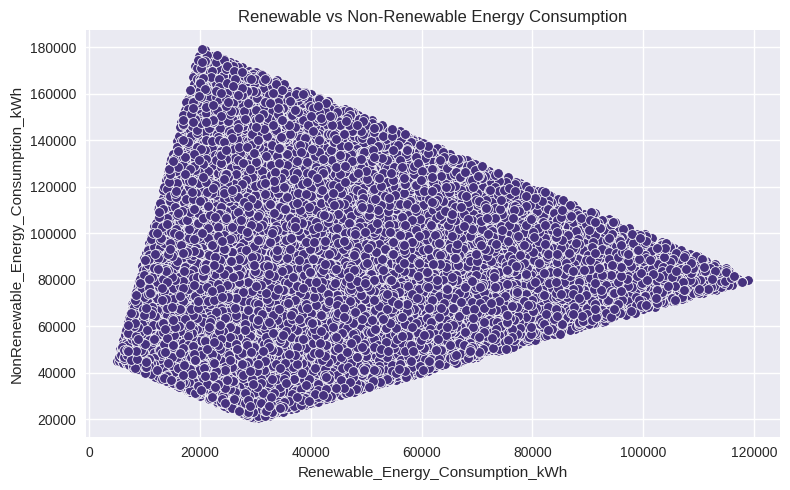

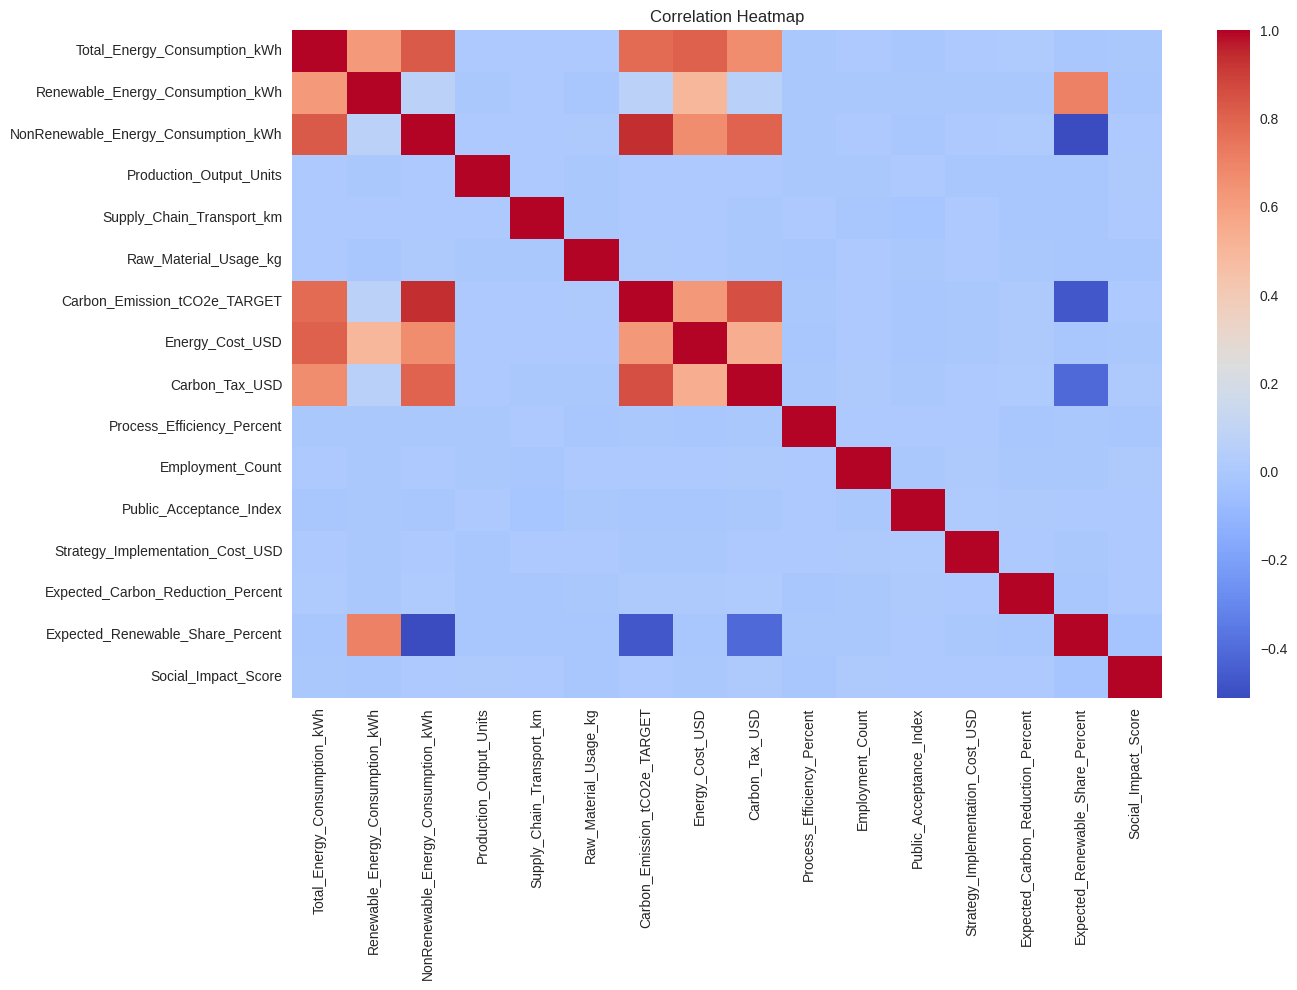

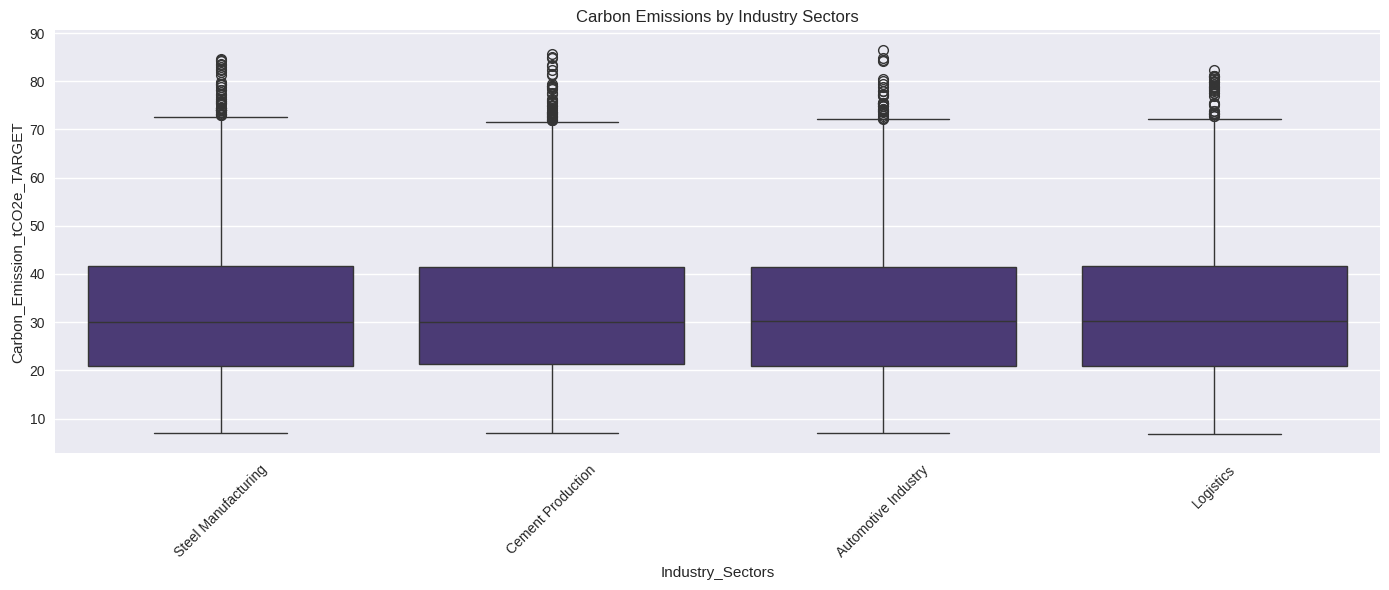

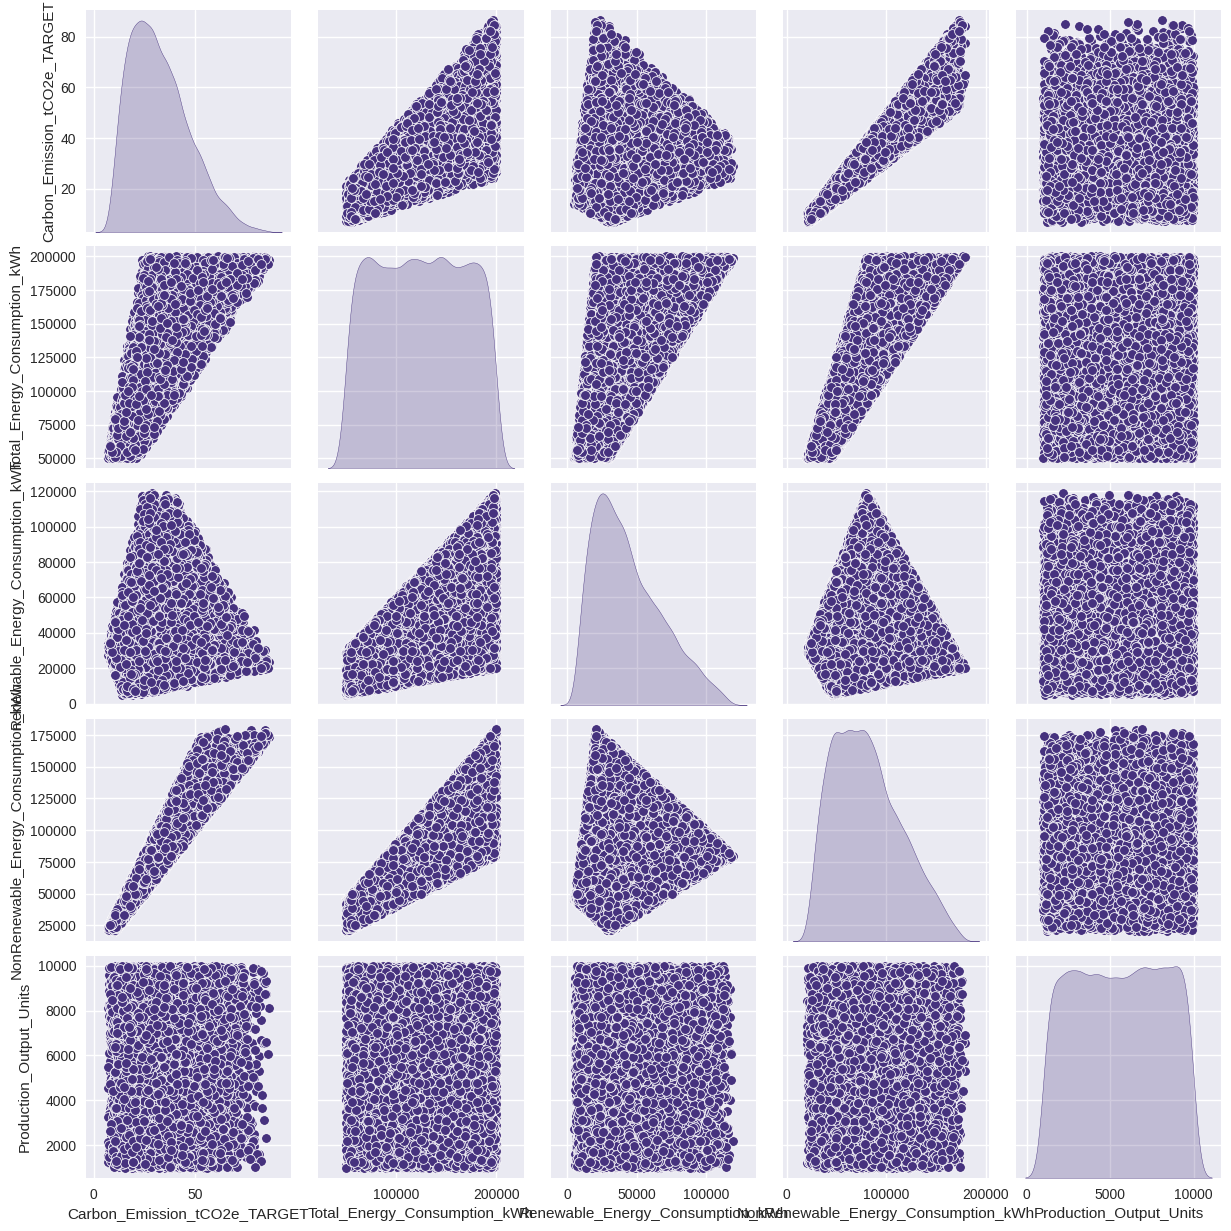

Industry_Sectors
Automotive Industry   32.40
Cement Production     32.36
Logistics             32.35
Steel Manufacturing   32.34
Name: Carbon_Emission_tCO2e_TARGET, dtype: float64

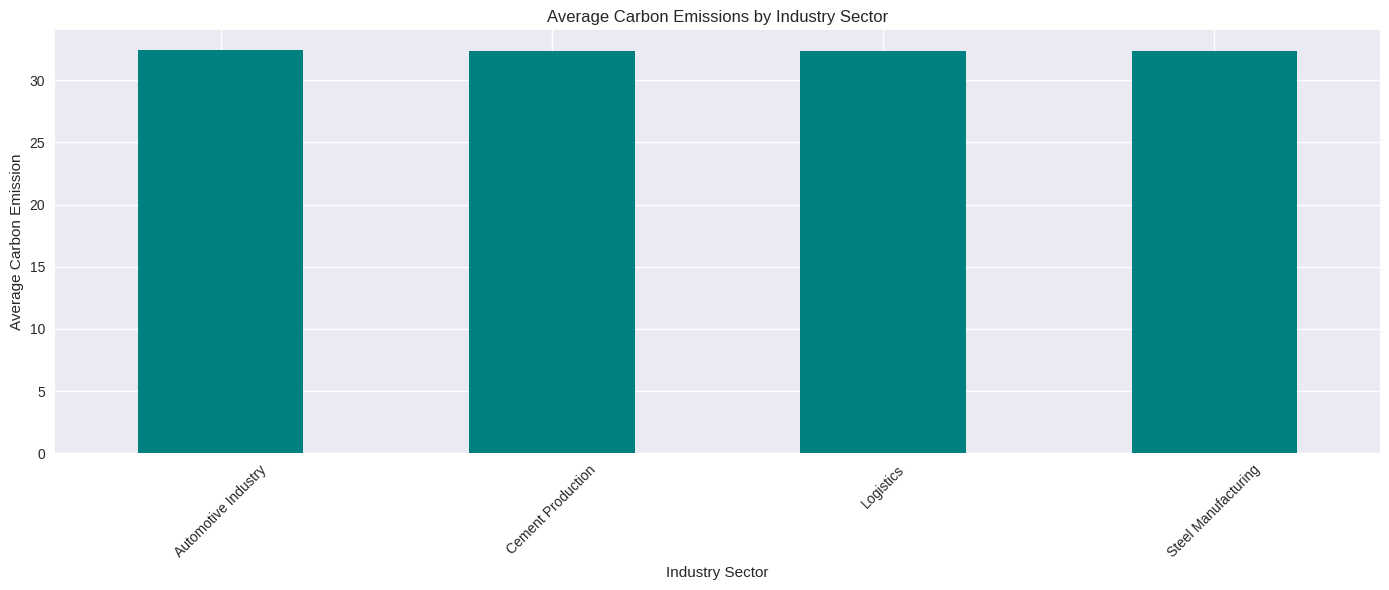

In [28]:
if target_col in df.columns and 'Total_Energy_Consumption_kWh' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Total_Energy_Consumption_kWh', y=target_col)
    plt.title('Carbon Emissions vs Total Energy Consumption')
    plt.tight_layout()
    plt.show()

if 'Renewable_Energy_Consumption_kWh' in df.columns and 'NonRenewable_Energy_Consumption_kWh' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Renewable_Energy_Consumption_kWh', y='NonRenewable_Energy_Consumption_kWh')
    plt.title('Renewable vs Non-Renewable Energy Consumption')
    plt.tight_layout()
    plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

if 'Industry_Sectors' in df.columns and target_col in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='Industry_Sectors', y=target_col)
    plt.title('Carbon Emissions by Industry Sectors')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

pairplot_cols = [
    'Carbon_Emission_tCO2e_TARGET',
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh',
    'Production_Output_Units'
]
pairplot_cols = [c for c in pairplot_cols if c in df.columns]

if len(pairplot_cols) >= 2:
    sns.pairplot(df[pairplot_cols], diag_kind='kde')
    plt.show()

if 'Industry_Sectors' in df.columns and target_col in df.columns:
    emissions_by_sector = df.groupby('Industry_Sectors')[target_col].mean().sort_values(ascending=False)
    display(emissions_by_sector)

    plt.figure(figsize=(14, 6))
    emissions_by_sector.plot(kind='bar', color='teal')
    plt.title('Average Carbon Emissions by Industry Sector')
    plt.xlabel('Industry Sector')
    plt.ylabel('Average Carbon Emission')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Time series analysis

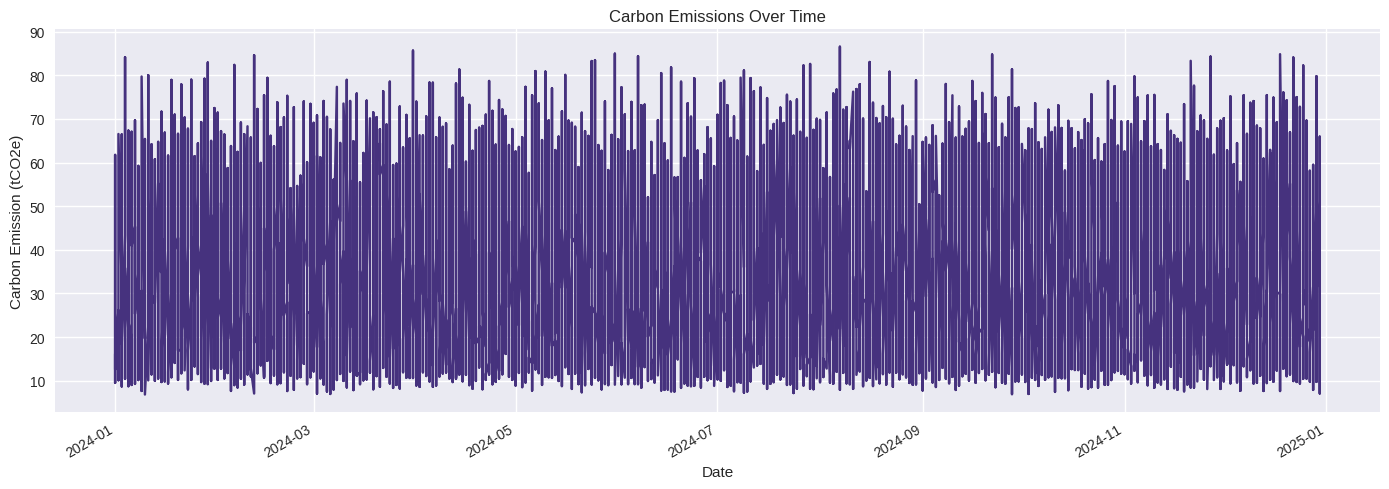

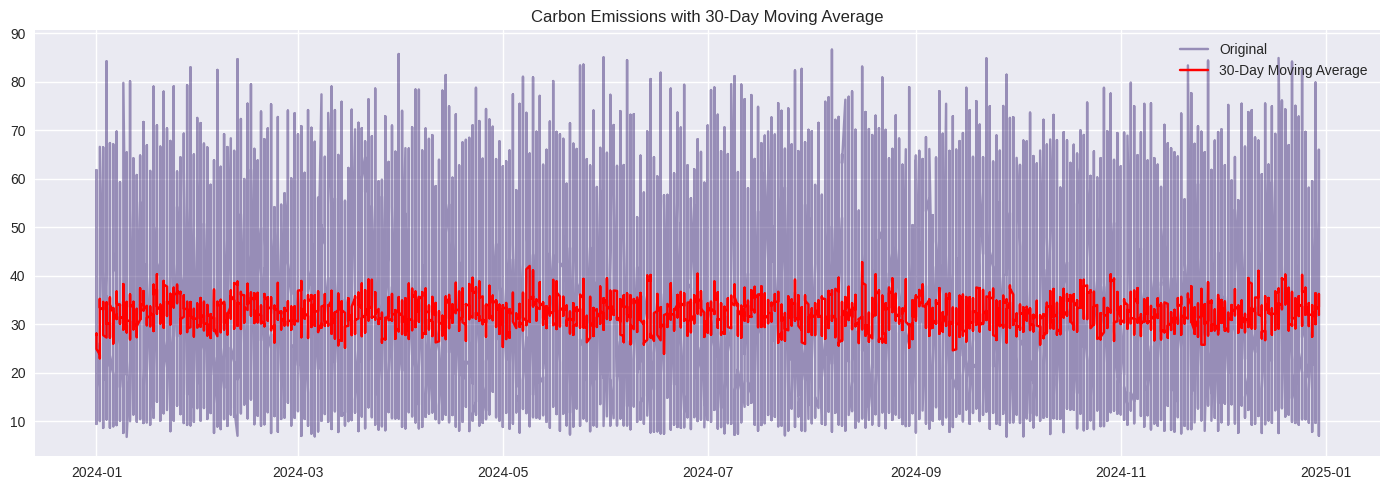

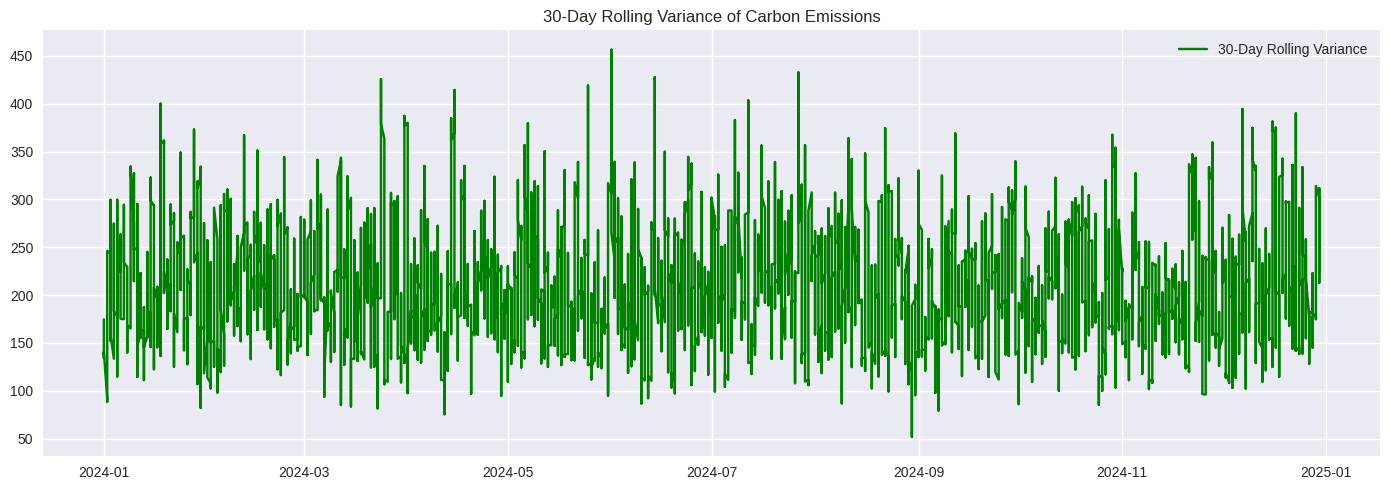

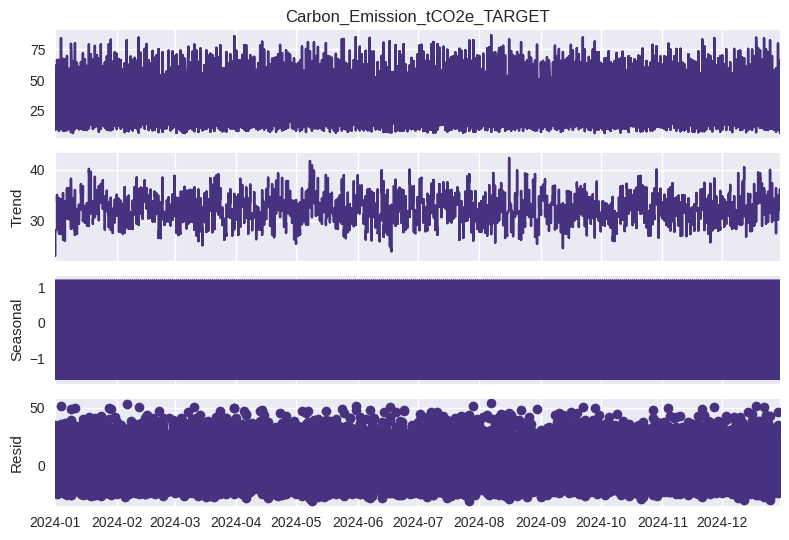

In [29]:
if 'Date' in df.columns and target_col in df.columns:
    df_ts = df.sort_values('Date').set_index('Date')

    plt.figure(figsize=(14, 5))
    df_ts[target_col].plot()
    plt.title('Carbon Emissions Over Time')
    plt.ylabel('Carbon Emission (tCO2e)')
    plt.tight_layout()
    plt.show()

    if temp_col is not None:
        plt.figure(figsize=(14, 5))
        df_ts[temp_col].plot(color='orange')
        plt.title(f'{temp_col} Trend Over Time')
        plt.tight_layout()
        plt.show()

    df_ts['Rolling_Mean_30'] = df_ts[target_col].rolling(window=30).mean()
    df_ts['Rolling_Var_30'] = df_ts[target_col].rolling(window=30).var()

    plt.figure(figsize=(14, 5))
    plt.plot(df_ts.index, df_ts[target_col], label='Original', alpha=0.5)
    plt.plot(df_ts.index, df_ts['Rolling_Mean_30'], label='30-Day Moving Average', color='red')
    plt.title('Carbon Emissions with 30-Day Moving Average')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(df_ts.index, df_ts['Rolling_Var_30'], label='30-Day Rolling Variance', color='green')
    plt.title('30-Day Rolling Variance of Carbon Emissions')
    plt.legend()
    plt.tight_layout()
    plt.show()

    try:
        from statsmodels.tsa.seasonal import seasonal_decompose
        decompose_result = seasonal_decompose(df_ts[target_col].dropna(), model='additive', period=30)
        decompose_result.plot()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Seasonal decomposition could not be completed:', e)

## 11. Support for Q1 to Q5

Q1: Which emission sources have the highest variability?


Total_Energy_Consumption_kWh          43106.62
NonRenewable_Energy_Consumption_kWh   33957.85
Renewable_Energy_Consumption_kWh      24291.67
Production_Output_Units                2597.58
Supply_Chain_Transport_km              1300.15
dtype: float64

Q2: Are emissions normally distributed?


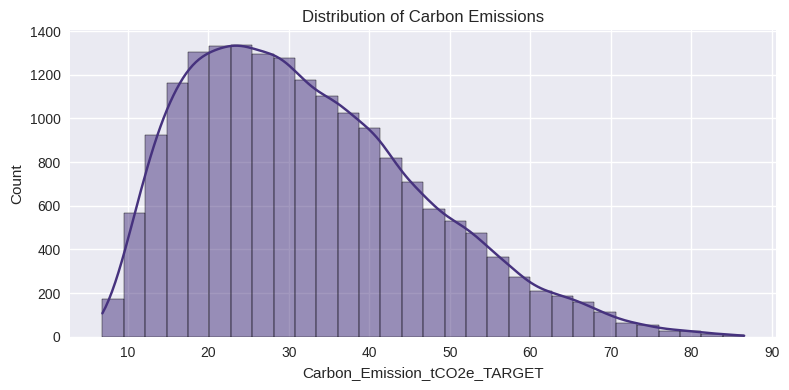

Q3: Which variables are strongly correlated with carbon emissions?


Carbon_Emission_tCO2e_TARGET           1.00
NonRenewable_Energy_Consumption_kWh    0.94
Carbon_Tax_USD                         0.86
Total_Energy_Consumption_kWh           0.78
Energy_Cost_USD                        0.63
Renewable_Energy_Consumption_kWh       0.07
Expected_Carbon_Reduction_Percent      0.01
Raw_Material_Usage_kg                  0.01
Social_Impact_Score                    0.01
Production_Output_Units                0.01
Employment_Count                       0.00
Supply_Chain_Transport_km              0.00
Strategy_Implementation_Cost_USD       0.00
Process_Efficiency_Percent            -0.00
Public_Acceptance_Index               -0.01
Expected_Renewable_Share_Percent      -0.48
Name: Carbon_Emission_tCO2e_TARGET, dtype: float64

Q4: Is there a trend in emissions?
Use the time series plot and the rolling mean plot to decide whether the trend is increasing, decreasing, or stable.
Q5: Do seasonal patterns exist?
Use the seasonal decomposition plot and repeated patterns in the time series to answer this question.


In [30]:
print('Q1: Which emission sources have the highest variability?')
variability = df[selected_cols].std().sort_values(ascending=False)
display(variability)

print('Q2: Are emissions normally distributed?')
if target_col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col], kde=True, bins=30)
    plt.title('Distribution of Carbon Emissions')
    plt.tight_layout()
    plt.show()

print('Q3: Which variables are strongly correlated with carbon emissions?')
if target_col in corr_matrix.columns:
    display(corr_matrix[target_col].sort_values(ascending=False))

print('Q4: Is there a trend in emissions?')
print('Use the time series plot and the rolling mean plot to decide whether the trend is increasing, decreasing, or stable.')

print('Q5: Do seasonal patterns exist?')
print('Use the seasonal decomposition plot and repeated patterns in the time series to answer this question.')

## 12. Final preview

In [31]:
display(df.head())

,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,12.56,3040.12,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,35.39,12837.43,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,30.45,16985.65,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,49.55,18192.00,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,16.90,6704.86,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing
